# Total Emissions Explorer

Descarga todos los archivos descompuestos desde S3 y genera gráficas de `total_emissions` por `primary_id` y `time_period`.

**Flujo:**
1. Configuración y conexión S3
2. Listar archivos en `MODEL_OUTPUT_PREFIX`
3. Listar y descargar todos los archivos descompuestos de `S3_DECOMPOSED_PREFIX`
4. Unir en un solo DataFrame con `primary_id`, `time_period`, `total_emissions`
5. Visualización

---
## 0. Imports

In [82]:
import os
import yaml
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from io import StringIO
from concurrent.futures import ThreadPoolExecutor, as_completed
try:
    from tqdm import tqdm
except Exception:
    tqdm = lambda x, **k: x

print("Imports OK")

Imports OK


---
## 1. Configuración

In [83]:
DIR_ID  = "130"
RUN_ID  = "sisepuede_run_2026-03-10t13;27;53.264959"

SCRIPT_DIR  = os.path.abspath(".")
CONFIG_PATH = os.path.join(SCRIPT_DIR, "config", "aws_credentials_config.yaml")

with open(CONFIG_PATH) as f:
    aws_config = yaml.safe_load(f)

PROFILE_NAME = aws_config["profile_name"]
BUCKET_NAME  = aws_config["bucket_name"]

RUN_DB_PREFIX        = f"run_database/{RUN_ID}/"
MODEL_OUTPUT_PREFIX  = f"{RUN_DB_PREFIX}model_output/region=uganda/model_output_{DIR_ID}/"
S3_DECOMPOSED_PREFIX = f"{RUN_DB_PREFIX}decomposed_outputs/"

print(f"Profile        : {PROFILE_NAME}")
print(f"Bucket         : {BUCKET_NAME}")
print(f"MODEL_OUTPUT   : {MODEL_OUTPUT_PREFIX}")
print(f"DECOMPOSED     : {S3_DECOMPOSED_PREFIX}")

Profile        : fabian
Bucket         : sisepuede-data
MODEL_OUTPUT   : run_database/sisepuede_run_2026-03-10t13;27;53.264959/model_output/region=uganda/model_output_130/
DECOMPOSED     : run_database/sisepuede_run_2026-03-10t13;27;53.264959/decomposed_outputs/


---
## 2. Conexión S3

In [84]:
session = boto3.Session(profile_name=PROFILE_NAME)
s3      = session.resource("s3")
bucket  = s3.Bucket(BUCKET_NAME)

try:
    s3.meta.client.head_bucket(Bucket=BUCKET_NAME)
    print("Conexión S3: OK")
except Exception as e:
    print(f"ERROR S3: {e}")

Conexión S3: OK


---
## 3. Listar archivos en MODEL_OUTPUT_PREFIX

In [85]:
model_objects = list(bucket.objects.filter(Prefix=MODEL_OUTPUT_PREFIX))

print(f"Archivos encontrados en MODEL_OUTPUT_PREFIX: {len(model_objects)}")
for obj in model_objects:
    size_mb = obj.size / 1024 / 1024
    print(f"  {obj.key.replace(MODEL_OUTPUT_PREFIX, '')}  ({size_mb:.1f} MB)")

Archivos encontrados en MODEL_OUTPUT_PREFIX: 1
  data.csv  (40.5 MB)


---
## 4. Listar archivos descompuestos en S3_DECOMPOSED_PREFIX

In [86]:
decomposed_objects = list(bucket.objects.filter(Prefix=S3_DECOMPOSED_PREFIX))

# Filtrar solo CSVs de emisiones
emission_keys = [
    obj.key for obj in decomposed_objects
    if obj.key.endswith(".csv") and "decomposed_emissions" in obj.key
]

print(f"Total archivos en decomposed_outputs : {len(decomposed_objects)}")
print(f"Archivos emission_total_*.csv        : {len(emission_keys)}")
if emission_keys:
    print(f"Ejemplo: {emission_keys[0]}")

Total archivos en decomposed_outputs : 3
Archivos emission_total_*.csv        : 3
Ejemplo: run_database/sisepuede_run_2026-03-10t13;27;53.264959/decomposed_outputs/region=uganda/decomposed_emissions_148/data.csv


---
## 5. Descargar todos los archivos descompuestos (paralelo)

Solo se mantienen las columnas `primary_id`, `time_period`, `total_emissions` para minimizar uso de memoria.

In [87]:
COLS_NEEDED = ["primary_id", "time_period", "total_emissions"]
MAX_WORKERS = 20

def download_emission_file(key):
    """Descarga un CSV desde S3 y retorna solo las columnas necesarias."""
    try:
        obj     = s3.Object(BUCKET_NAME, key)
        content = obj.get()["Body"].read().decode("utf-8")
        df      = pd.read_csv(StringIO(content), usecols=COLS_NEEDED)
        return df
    except Exception as e:
        print(f"ERROR descargando {key}: {e}")
        return None


frames = []
errors = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(download_emission_file, key): key for key in emission_keys}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Descargando"):
        result = future.result()
        if result is not None:
            frames.append(result)
        else:
            errors.append(futures[future])

print(f"\nDescargados  : {len(frames)} archivos")
print(f"Errores      : {len(errors)} archivos")


Descargados  : 3 archivos
Errores      : 0 archivos


---
## 6. Unir todos los DataFrames

In [88]:
df = pd.concat(frames, ignore_index=True)
df = df.sort_values(["primary_id", "time_period"]).reset_index(drop=True)

n_ids = df["primary_id"].nunique()
print(f"Shape total       : {df.shape}")
print(f"primary_ids únicos: {n_ids}")
print(f"time_period range : {df['time_period'].min()} – {df['time_period'].max()}")
print(f"total_emissions   : min={df['total_emissions'].min():.2f}, max={df['total_emissions'].max():.2f}")
df.head()

Shape total       : (5668, 3)
primary_ids únicos: 109
time_period range : 4 – 55
total_emissions   : min=100.56, max=195.15


,primary_id,time_period,total_emissions
0,6521694,4,111.777536
1,6521694,5,113.675328
2,6521694,6,113.472629
3,6521694,7,116.025591
4,6521694,8,118.680971


---
## 7. Visualización de total_emissions

### 7a. Fan chart — distribución por time_period

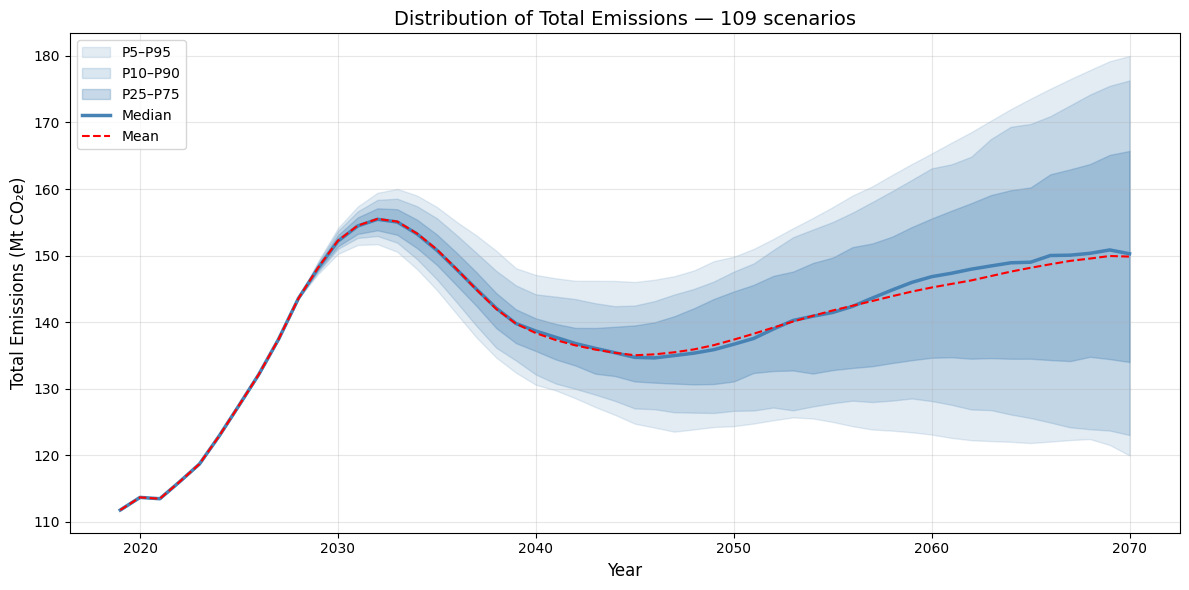

In [89]:
# Calcular percentiles por time_period
stats = df.groupby("time_period")["total_emissions"].describe(
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
).reset_index()

years = stats["time_period"] + 2015  # time_period 0 = 2015

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(years, stats["5%"],  stats["95%"],  alpha=0.15, color="steelblue", label="P5–P95")
ax.fill_between(years, stats["10%"], stats["90%"],  alpha=0.20, color="steelblue", label="P10–P90")
ax.fill_between(years, stats["25%"], stats["75%"],  alpha=0.30, color="steelblue", label="P25–P75")
ax.plot(years, stats["50%"],  color="steelblue", linewidth=2.5, label="Median")
ax.plot(years, stats["mean"], color="red",       linewidth=1.5, linestyle="--", label="Mean")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total Emissions (Mt CO₂e)", fontsize=12)
ax.set_title(f"Distribution of Total Emissions — {n_ids:,} scenarios", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("total_emissions_fan_chart.png", dpi=150)
plt.show()


### 7b. Box plot por year

/var/folders/fj/jc6_dph55kg8wg_040b7gk980000gn/T/ipykernel_73641/3419000395.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grouped, labels=years_list, patch_artist=True,


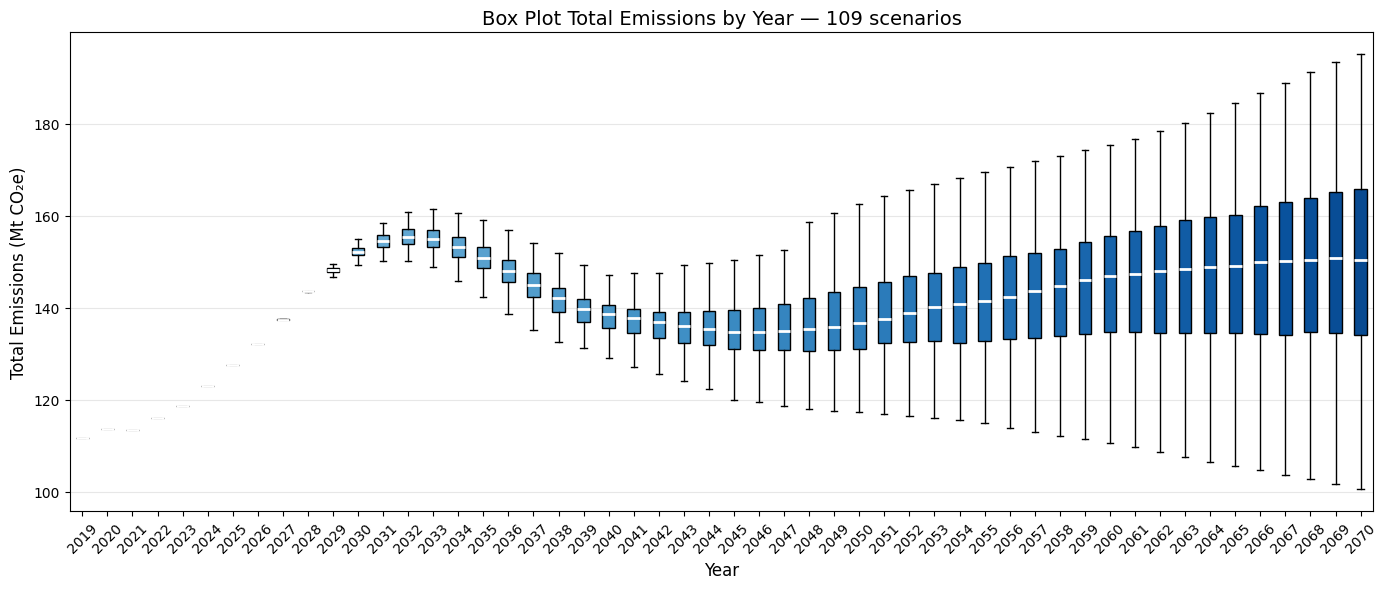

Guardado: total_emissions_boxplot.png


In [91]:
df_plot = df.copy()
df_plot["year"] = df_plot["time_period"] + 2015

grouped = [group["total_emissions"].values for _, group in df_plot.groupby("year")]
years_list = sorted(df_plot["year"].unique())

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(grouped, labels=years_list, patch_artist=True,
                showfliers=False, medianprops=dict(color="white", linewidth=2))

colors = cm.Blues(np.linspace(0.4, 0.9, len(grouped)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total Emissions (Mt CO₂e)", fontsize=12)
ax.set_title(f"Box Plot Total Emissions by Year — {n_ids:,} scenarios", fontsize=14)
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig("total_emissions_boxplot.png", dpi=150)
plt.show()
print("Guardado: total_emissions_boxplot.png")

### 7c. Histograma de total_emissions en un año de referencia (2022)

### 7c. Spaghetti — una línea por primary_id

/var/folders/fj/jc6_dph55kg8wg_040b7gk980000gn/T/ipykernel_73641/3430461563.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


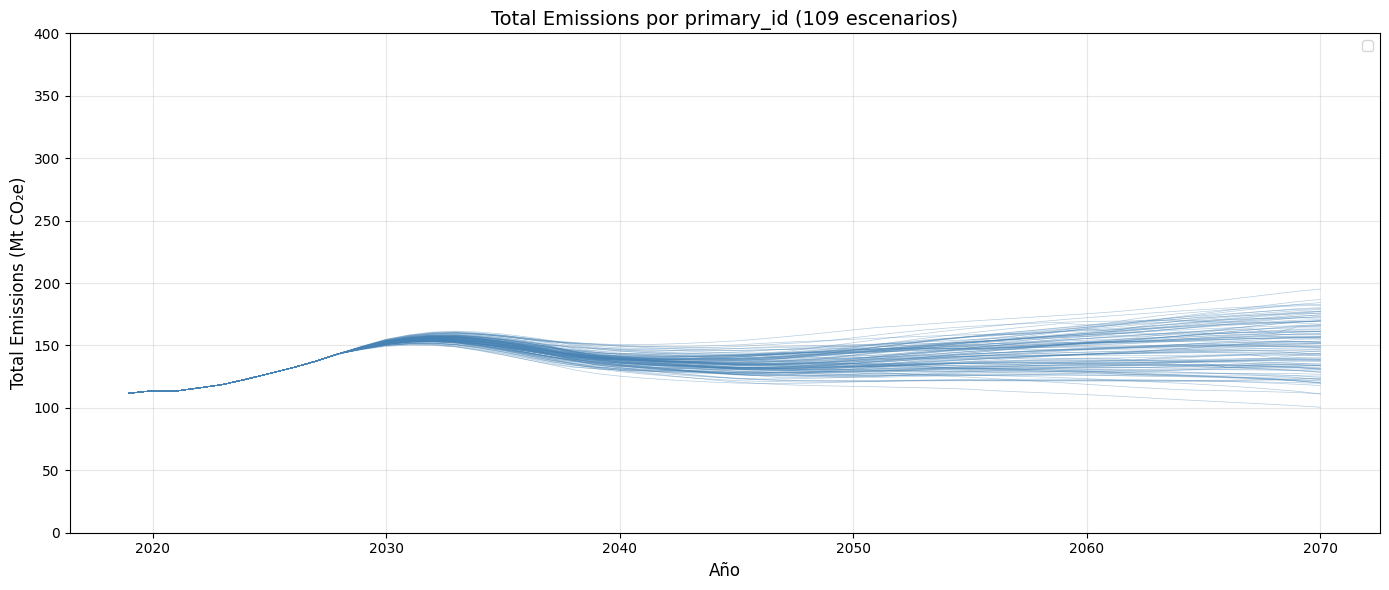

In [92]:
pivot = df.pivot_table(index="time_period", columns="primary_id", values="total_emissions")
years_arr = pivot.index.values + 2015

y_lo = df["total_emissions"].quantile(0.01)
y_hi = df["total_emissions"].quantile(0.99)

fig, ax = plt.subplots(figsize=(14, 6))

alpha = max(0.02, min(0.3, 10 / len(pivot.columns)))

# Todas las líneas excepto baseline
non_baseline_cols = [c for c in pivot.columns if c != 0]
ax.plot(years_arr, pivot[non_baseline_cols].values, color="steelblue", linewidth=0.5, alpha=0.4)

# Baseline en rojo
if 0 in pivot.columns:
    baseline_vals = pivot[0].values
    ax.plot(years_arr, baseline_vals, color="red", linewidth=2, label="Baseline (primary_id=0)", zorder=5)

    # Anotación al final de la línea
    ax.annotate(
        "Baseline",
        xy=(years_arr[-1], baseline_vals[-1]),
        xytext=(8, 0),
        textcoords="offset points",
        color="red",
        fontsize=10,
        fontweight="bold",
        va="center",
    )

ax.set_ylim(0, 400)
ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("Total Emissions (Mt CO₂e)", fontsize=12)
ax.set_title(f"Total Emissions por primary_id ({len(pivot.columns):,} escenarios)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("total_emissions_spaghetti.png", dpi=150)
plt.show()

---
## 8. Guardar base unificada (opcional)

In [ ]:
SCRIPT_DIR

In [ ]:
df_plot.to_csv(f"{SCRIPT_DIR}/tmp/total_emissions_by_primary_id.csv", index=False)